# Text Mining

Text mining (also referred to as text analytics) is an artificial intelligence technology that uses natural language processing (NLP) to transform the free (unstructured) text in documents and databases into normalized, structured data suitable for analysis or to drive machine learning (ML) algorithms. NLP is a subfield of linguistics, computer science, and artificial intelligence concerned with the interactions between computers and human language, in particular how to program computers to process and analyze large amounts of natural language data.

In this notebook, we discuss how to combine simple machine learning models with feature engeering for text mining. In the future, we will go over some of the state-of-the-art techniques for NLP using deep learning.
    
**Requirements:** You will need to have NLTK installed, along with downloading the corpus for stopwords. To download everything with a conda installation, **run the code below in terminal:** ``conda install nltk``

In [1]:
# Import the library
import nltk 
import pandas as pd

## SMS Spam Collection Data Set

We'll be text mining a dataset of more than 5000 SMS phone messages from the [UCI datasets](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection) and identifying spam meassages.

We use ``rstrip()`` plus a list comprehension to get a list of all the lines of text messages:

In [2]:
messages = [line.rstrip() for line in open('smsspamcollection/SMSSpamCollection.txt')]
print(len(messages))

5574


In [3]:
type(messages[0])

str

A collection of texts is also sometimes called "corpus". Let's print the first ten messages and number them using **enumerate**:

In [4]:
for message_no, message in enumerate(messages[:10]):
    print(message_no, message)
    print()

0 ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

1 ham	Ok lar... Joking wif u oni...

2 spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

3 ham	U dun say so early hor... U c already then say...

4 ham	Nah I don't think he goes to usf, he lives around here though

5 spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

6 ham	Even my brother is not like to speak with me. They treat me like aids patent.

7 ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

8 spam	WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. V

This is a [TSV](http://en.wikipedia.org/wiki/Tab-separated_values) (tab separated values) file, where the first column is a label saying whether the given message is a normal message (commonly known as "ham") or "spam". The second column is the message itself.

Using these labeled ham and spam examples, we'll **train a machine learning model to learn to discriminate between ham/spam automatically**. Then, with a trained model, we'll be able to **classify arbitrary unlabeled messages** as ham or spam.

We'll use ``read_csv`` and make note of the ``sep`` argument, we can also specify the desired column names by passing in a list of ``names``.

In [5]:
df = pd.read_csv('smsspamcollection/SMSSpamCollection.txt', sep='\t',
                           names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Convert string labels into binary encodings, ``ham``= 0 and ``spam`` = 1:

In [46]:
df['label'] = pd.get_dummies(df['label'],drop_first=True,dtype=int)
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


## Exploratory Data Analysis

In [48]:
print('There are', df['label'].value_counts()[0] ,'hams,', round(df['label'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('There are', df['label'].value_counts()[1] ,'spams,', round(df['label'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

There are 4825 hams, 86.59 % of the dataset
There are 747 spams, 13.41 % of the dataset


In [49]:
df.describe()

,label,length
count,5572.000000,5572.000000
mean,0.134063,80.489950
std,0.340751,59.942907
min,0.000000,2.000000
25%,0.000000,36.000000
50%,0.000000,62.000000
75%,0.000000,122.000000
max,1.000000,910.000000


Let's use ``groupby`` to use describe by label, this way we can begin to think about the features that separate ham and spam!

In [50]:
df.groupby('label').describe()

length                                                         
        count        mean        std   min    25%    50%    75%    max
label                                                                 
0      4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
1       747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0

Let's make a new column to detect how long the text messages are:

In [51]:
df['length'] = df['message'].apply(len)
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


### Data Visualization
Let's visualize this! Let's do the imports:

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

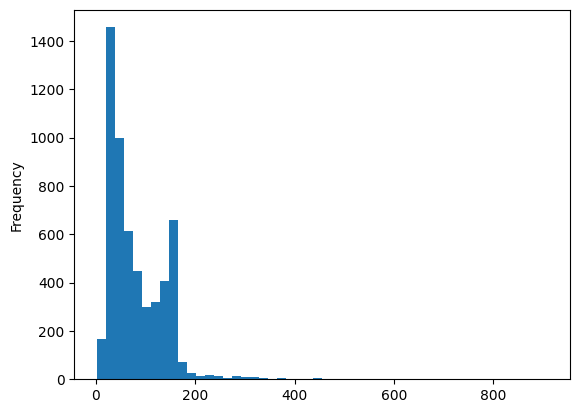

In [53]:
df['length'].plot(bins=50, kind='hist') 
plt.show()

In [54]:
df.length.describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

The longest message contains 910 characters, we can use masking to find this message:

In [55]:
df[df['length'] == 910]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

## Text Preprocessing

The main issue is that the data is all in text format (strings). Here we'll convert the raw messages (sequence of characters) into vectors (sequences of numbers).

Firstly, we write a function that will split a message into its individual words and return a list. We'll also remove very common words ('the', 'a', etc..). **Stop words** are commonly used in text mining and NLP to eliminate words that are so commonly used that they carry very little useful information. 

To do this we will take advantage of the NLTK library. It's a standard library in Python for processing text. We can just use ``apply()`` in Pandas do process all the text in the ``DataFrame``. We can just take advantage of Python's built-in ``string`` library to get a quick list of all the possible punctuation:

In [56]:
import string

In [57]:
mess = 'Sample message. Notice: it has punctuation.'

print(mess)

Sample message. Notice: it has punctuation.


In [58]:
# Check characters to see if they are in punctuation
nopunc = [char for char in mess if char not in string.punctuation]

# Join the characters again to form the string.
nopunc = ''.join(nopunc)

print(nopunc)

Sample message Notice it has punctuation


Now let's see how to remove stopwords. Stopwords are the English words which does not add much meaning to a sentence. They can safely be ignored without sacrificing the meaning of the sentence. For example, the words like the, he, have etc. We can impot a list of english stopwords from NLTK (check the documentation for more languages and info).

In [59]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/penghangyin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
from nltk.corpus import stopwords
stopwords.words('english')[0:10] # Show some stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [61]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [62]:
nopunc.split()

['Sample', 'message', 'Notice', 'it', 'has', 'punctuation']

In [63]:
# Now just remove any stopwords
clean_mess = [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [64]:
clean_mess

['Sample', 'message', 'Notice', 'punctuation']

Put both of these together in a function `text_process` to apply it to our DataFrame later on:

In [65]:
def text_process(mess):
    """
    Takes in a string of text, then performs the following:
    1. Remove all punctuation
    2. Remove all stopwords
    3. Returns a list of the cleaned text
    """
    # Check characters to see if they are in punctuation
    nopunc = [char for char in mess if char not in string.punctuation]

    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    
    # Remove any stopwords
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

Here is the original DataFrame again:

In [66]:
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


Now let's "tokenize" these messages. Tokenization is just the term used to describe the process of converting the normal text strings in to a list of tokens (words that we actually want).

Let's see an example output on on column:

In [67]:
# Check to make sure its working
df['message'].head(5).apply(text_process)

0    [Go, jurong, point, crazy, Available, bugis, n...
1                       [Ok, lar, Joking, wif, u, oni]
2    [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3        [U, dun, say, early, hor, U, c, already, say]
4    [Nah, dont, think, goes, usf, lives, around, t...
Name: message, dtype: object

## TF-IDF Vectorization

Now we need to convert each of those messages into a vector the Sklearn's algorithm models can work with. Each vector will have as many dimensions as there are unique words in the SMS corpus. This model will convert a collection of text documents to a matrix of scores/weights.

### TF-IDF 
stands for **term frequency-inverse document frequency**, and the TF-IDF weight is a weight often used in information retrieval and text mining. This weight is a statistical measure used to evaluate how important a word is to a document in a collection or corpus. The importance increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus. 

Typically, the TF-IDF weight is composed by two terms: 

 - Normalized term frequency (TF), a.k.a. the number of times a word appears in a document, divided by the total number of words in that document
 
 - Inverse document frequency (IDF), computed as the logarithm of the number of the documents in the corpus divided by the number of documents where the specific term appears.

**TF: Term Frequency**, which measures how frequently a term occurs in a document. Since every document is different in length, it is possible that a term would appear much more times in long documents than shorter ones. Thus, the term frequency is often divided by the document length (aka. the total number of terms in the document) as a way of normalization: 

*TF(t) = (Number of times term t appears in a document) / (Total number of terms in the document).*

**IDF: Inverse Document Frequency**, which measures how important a term is. While computing TF, all terms are considered equally important. However it is known that certain terms, such as "is", "of", and "that", may appear a lot of times but have little importance. Thus we need to **weigh down the frequent terms while scale up the rare ones**, by computing the following: 

*IDF(t) = log (Total number of documents / Number of documents with term t in it).*

See below for a simple example.

**Example:**

Consider a document containing 100 words wherein the word cat appears 3 times. 

The term frequency (i.e., tf) for cat is then (3 / 100) = 0.03. Now, assume we have 10 million documents and the word cat appears in one thousand of these. Then, the inverse document frequency (i.e., idf) is calculated as log(10,000,000 / 1,000) = 4. Thus, the TF-IDF weight is the product of these quantities: 0.03 * 4 = 0.12.

We can imagine this as a 2-Dimensional matrix. Where the one dimension is the entire vocabulary (1 column per word) and the other dimension are the actual documents, in this case a row per text message. 

For example:

<table border = “1“>
<tr>
<th></th> <th>Word 1 score</th> <th>Word 2 score</th> <th>...</th> <th>Word N score</th> 
</tr>
<tr>
<td><b>Message 1</b></td><td> 0.8765 </td><td> 0</td><td>...</td><td> 0</td>
</tr>
<tr>
<td><b>Message 2</b></td><td> 0</td><td> 0</td><td>...</td><td>  0.3261</td>
</tr>
<tr>
<td><b> $\vdots$ </b></td> <td> $\vdots$</td><td>$\vdots$</td><td>...</td><td>$\vdots$</td>
</tr>
<tr>
<td><b>Message  M</b></td> <td>0  </td><td>0.2198 </td><td>...</td><td>0</td>
</tr>
</table>


Since there are so many messages and vocabularies, we can expect a lot of zero scores for the absence of a word in documents. Because of this, Scik-Learn will output a [Sparse Matrix](https://en.wikipedia.org/wiki/Sparse_matrix).

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

There are a lot of arguments and parameters that can be passed to the TfidfVectorizer. In this case we will just specify the **analyzer** to be our own previously defined function:

In [69]:
tfidf_transformer = TfidfVectorizer(analyzer=text_process).fit(df['message'])

Size of vocabulary:

In [70]:
print(len(tfidf_transformer.vocabulary_))

11425


Let's take one text message and get its bag-of-words counts as a vector, putting to use our new `bow_transformer`:

In [71]:
message4 = df['message'][3]
print(message4)

U dun say so early hor... U c already then say...


Now let's see its vector representation:

In [72]:
tfidf4 = tfidf_transformer.transform([message4])
print(tfidf4)
print()
print(tfidf4.shape)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 11425)>
  Coords	Values
  (0, 4068)	0.40832589933384067
  (0, 4629)	0.26619801906087187
  (0, 5261)	0.29729957405868723
  (0, 6204)	0.29953799723697416
  (0, 6222)	0.3187216892949149
  (0, 7186)	0.4389365653379857
  (0, 9554)	0.5385626262927564

(1, 11425)


This means that there are 7 unique words in message number 4 (after removing common stop words). We go ahead and check some of the words:

In [73]:
print(tfidf_transformer.get_feature_names_out()[4068])
print(tfidf_transformer.get_feature_names_out()[9554])

U
say


We can check the IDF (inverse document frequency) of the word `"U"` and of word `"say"`

In [74]:
print(tfidf_transformer.idf_[tfidf_transformer.vocabulary_['U']])
print(tfidf_transformer.idf_[tfidf_transformer.vocabulary_['say']])

3.966206571809915
5.231239632897098


Finally we use ``transform`` the entire DataFrame of messages. Let's go ahead and check out how the features matrix for the entire SMS corpus is a large, sparse matrix:

In [75]:
message_tfidf = tfidf_transformer.transform(df['message'])

In [76]:
print('Shape of Sparse Matrix: ', message_tfidf.shape)
print('Amount of Non-Zero occurences: ', message_tfidf.nnz)

Shape of Sparse Matrix:  (5572, 11425)
Amount of Non-Zero occurences:  50548


In [77]:
sparsity = (100.0 * message_tfidf.nnz / (message_tfidf.shape[0] * message_tfidf.shape[1]))
print('sparsity: {:f}% non zero entries'.format(sparsity))

sparsity: 0.079403% non zero entries


## Classification

With messages represented as vectors, we can finally train our spam/ham classifier. We can actually use almost any sort of classification algorithms.

We'll be using XGBoost classifier here:

In [78]:
from xgboost import XGBClassifier

### Train-Test Split

[``StratifiedShuffledSplit``](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html?highlight=stratified#sklearn.model_selection.StratifiedShuffleSplit) provides train/test indices to split data in train/test sets. This is cross-validation object which **preserves the orignal percentage of samples for each class after splitting.** Here we only use it for train-test split but not cross validation. Set `n_splits = 1` because we only do one train-test split.

In [79]:
from sklearn.model_selection import StratifiedShuffleSplit

In [80]:
X = df['message']
y = df['label']

In [81]:
sss = StratifiedShuffleSplit(n_splits=1, test_size = 0.2, random_state = 0)

for train_index, test_index in sss.split(X, y):
    print('# train samples:' , len(train_index) , ' Train index:', train_index)
    print('# test samples:' , len(test_index), ' Test index:', test_index)
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y[train_index], y[test_index]

# train samples: 4457  Train index: [1257 5461 1613 ...  245 1235 3361]
# test samples: 1115  Test index: [2461  461 2628 ... 3681 2895 3100]


The test size is 20% of the entire dataset (1115 messages out of total 5572), and the training is the rest (4457 out of 5572). Note the default split would have been 30/70.

### Creating a Data Pipeline

Let's run our model again and then predict for the test set. We will use Scik-Learn's [pipeline](http://scikit-learn.org/stable/modules/pipeline.html) capabilities to store a pipeline of workflow:

In [82]:
from sklearn.pipeline import Pipeline

In [83]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer=text_process)),  # strings to TF-IDF scores
    ('classifier', XGBClassifier(booster='gbtree', objective='binary:logistic', random_state=101))  
    # train on TF-IDF vectors w/ XGBoost classifier
])

Now we can directly pass message text data and the pipeline will do the pre-processing. We can treat it as a model/estimator API:

In [84]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


###  Model Evaluation

Now we want to determine how well our model will do overall on the test dataset.  There are quite a few possible metrics for evaluating model performance. Which one is the most important depends on the task and the business effects of decisions based off of the model. For example, the cost of mis-predicting "spam" as "ham" (false negatives) is probably much lower than mis-predicting "ham" as "spam" (false positives).

In [85]:
pred_train = pipeline.predict(X_train)

In [86]:
print('predicted:', pred_train[1])
print('expected:', y_train.iloc[1])

predicted: 0
expected: 0


In [87]:
from sklearn.metrics import classification_report

In [88]:
print('Train:\n', classification_report(y_train, pred_train))

Train:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3859
           1       1.00      0.91      0.95       598

    accuracy                           0.99      4457
   macro avg       0.99      0.96      0.97      4457
weighted avg       0.99      0.99      0.99      4457



Train:



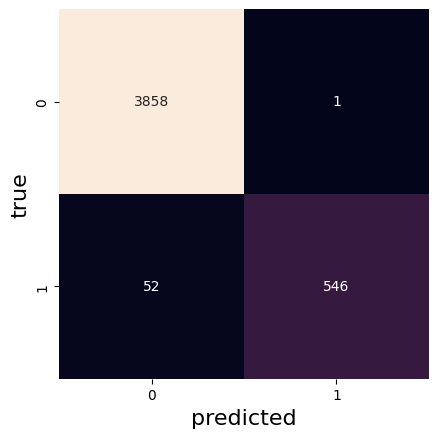

In [89]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_train, pred_train)
print('Train:\n')
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('predicted' , fontsize = 16)
plt.ylabel('true', fontsize = 16);
plt.show()

Now we have a classification report for our model on a test set.

In [90]:
pred_test = pipeline.predict(X_test)

In [91]:
print('Test:\n', classification_report(y_test, pred_test))

Test:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.98      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [92]:
from sklearn.metrics import confusion_matrix

Test:



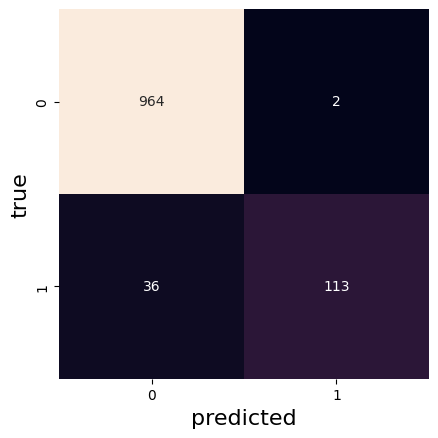

In [93]:
mat = confusion_matrix(y_test, pred_test)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
print('Test:\n')
plt.ylabel('true', fontsize = 16)
plt.xlabel('predicted', fontsize = 16);
plt.show()

### GridSearchCV

Let's see if we can use ``GridSearchCV`` to imporve the model's performance. We'll use ``'f1'`` for scoring.

In [94]:
from sklearn.model_selection import GridSearchCV

We need to replace ``XGBClassifier`` with its ``GridSearchCV`` counterpart when creating pipeline.

In [95]:
param_grid = {'n_estimators': [50, 100, 300],
             'learning_rate': [0.05, 0.1, 0.3],
             'colsample_bytree': [0.8, 1],
             }
grid = GridSearchCV(XGBClassifier(booster='gbtree', objective='binary:logistic'), \
                    param_grid, cv=5, scoring = 'f1', verbose = 3, refit = True)

In [96]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer=text_process)),  # strings to TF-IDF scores
    ('classifier', grid)  # train on TF-IDF vectors
])

In [97]:
pipeline.fit(X_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=50;, score=0.751 total time=   0.2s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=50;, score=0.776 total time=   0.1s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=50;, score=0.721 total time=   0.2s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=50;, score=0.747 total time=   0.2s
[CV 5/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=50;, score=0.764 total time=   0.2s
[CV 1/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=100;, score=0.806 total time=   0.3s
[CV 2/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=100;, score=0.821 total time=   0.3s
[CV 3/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=100;, score=0.777 total time=   0.3s
[CV 4/5] END colsample_bytree=0.8, learning_rate=0.05, n_estimators=100;, score=0.800 total time=   0.3s

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [98]:
print(grid.best_score_)

0.8761659192825112


In [99]:
print(grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.3, 'n_estimators': 100}


Now evaluate:

In [100]:
pred_train = pipeline.predict(X_train)

In [101]:
print('Train:\n', classification_report(y_train, pred_train))

Train:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3859
           1       1.00      0.92      0.96       598

    accuracy                           0.99      4457
   macro avg       0.99      0.96      0.97      4457
weighted avg       0.99      0.99      0.99      4457



Train:



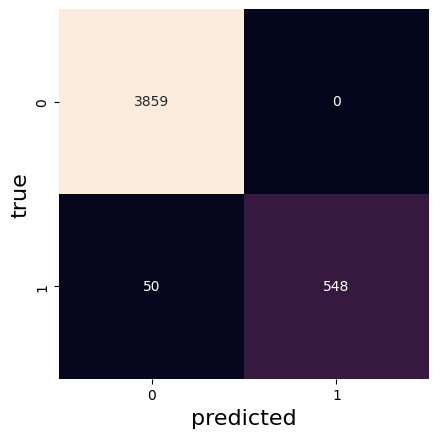

In [102]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_train, pred_train)
print('Train:\n')
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
plt.ylabel('true', fontsize = 16)
plt.xlabel('predicted', fontsize = 16);
plt.show()

Now we have a classification report for our model on a test set.

In [103]:
pred_test = pipeline.predict(X_test)

In [104]:
print('Test:\n', classification_report(y_test, pred_test))

Test:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.98      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.97      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Test:



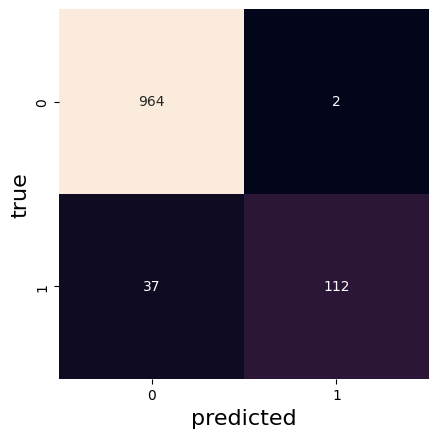

In [105]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, pred_test)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
print('Test:\n')
plt.ylabel('true', fontsize = 16)
plt.xlabel('predicted', fontsize = 16);
plt.show()

The best ``GridSearchCV`` model is empirically no better than using the default hyperparameters.